<a href="https://colab.research.google.com/github/Arczisork/Sztuczna-inteligencja/blob/main/lab3/Sztuczna_lab3_wiecej_liczb_rozpoznaje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds


In [66]:
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']
num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)


In [67]:
def scale(image, label):
  image = tf.cast(image, tf.float32)
  image /= 255
  return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

In [68]:
from tensorflow.python.module.module import valid_identifier
BUFFER_SIZE= 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)


In [69]:
BATCH_SIZE = 100
train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)
validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape, validation_targets.shape)


(6000, 28, 28, 1) (6000,)


In [70]:
input_size = 784
output_size = 10
hidden_layer_size = 50

model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
  tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
  tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
  tf.keras.layers.Dense(output_size, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [71]:
NUM_EPOCHS = 10
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)
model.fit(train_data,
          epochs=NUM_EPOCHS,
          callbacks=[early_stopping],
          validation_data=(validation_inputs, validation_targets),
          verbose=1
)

Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8816 - loss: 0.4202 - val_accuracy: 0.9390 - val_loss: 0.2202
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9463 - loss: 0.1830 - val_accuracy: 0.9483 - val_loss: 0.1693
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9591 - loss: 0.1376 - val_accuracy: 0.9572 - val_loss: 0.1416
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9674 - loss: 0.1103 - val_accuracy: 0.9630 - val_loss: 0.1209
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9726 - loss: 0.0920 - val_accuracy: 0.9650 - val_loss: 0.1131
Epoch 6/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9769 - loss: 0.0779 - val_accuracy: 0.9638 - val_loss: 0.1118
Epoch 7/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9802 - loss: 0.0674 - val_accuracy: 0.9680 - val_loss: 0.1057
Epoch 8/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9826 - loss: 0.0588 - val_accura

In [72]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 932ms/step - accuracy: 0.9718 - loss: 0.0925
Test loss: 0.09. Test accuracy: 97.18%



Plik: mnist8.png
Przewidziana cyfra: 8
Pewność modelu: 99.98%
Model rozpoznał poprawnie ✅


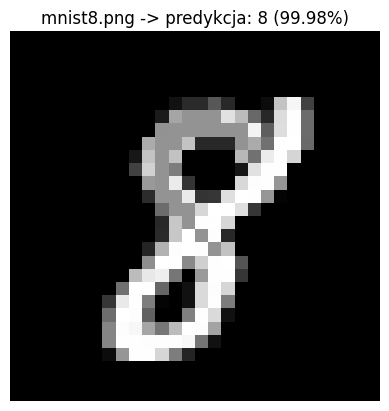


Plik: mnist6.png
Przewidziana cyfra: 6
Pewność modelu: 100.00%
Model rozpoznał poprawnie ✅


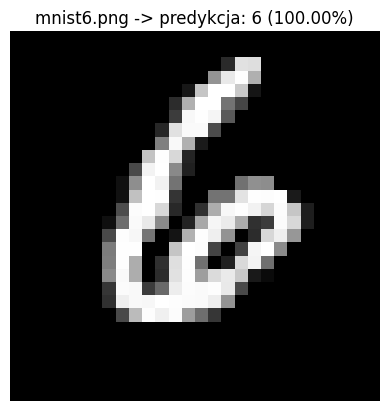


Plik: mnist7.png
Przewidziana cyfra: 7
Pewność modelu: 95.29%
Model rozpoznał poprawnie ✅


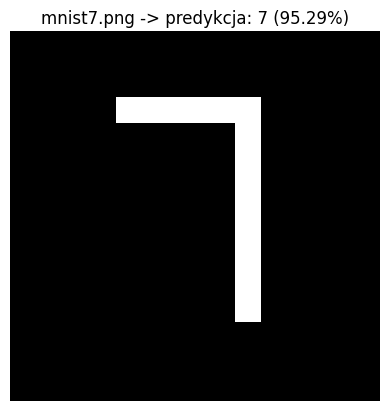


Skuteczność dla 3 obrazków: 100.00%


In [75]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

images = [
    ("mnist8.png", 8),
    ("mnist6.png", 6),
    ("mnist7.png", 7)
]

correct = 0

for img_path, true_label in images:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Nie udało się wczytać pliku: {img_path}")
        continue

    img_resized = cv2.resize(img, (28, 28))
    img_resized = img_resized.astype("float32") / 255.0

    img_input = np.expand_dims(img_resized, axis=0)
    img_input = np.expand_dims(img_input, axis=-1)

    predictions = model.predict(img_input, verbose=0)
    predicted_digit = np.argmax(predictions)
    confidence = np.max(predictions) * 100

    print(f"\nPlik: {img_path}")
    print("Przewidziana cyfra:", predicted_digit)
    print("Pewność modelu: {:.2f}%".format(confidence))

    if predicted_digit == true_label:
        print("Model rozpoznał poprawnie ✅")
        correct += 1
    else:
        print(f"Model się pomylił ❌ (prawidłowa: {true_label})")

    plt.imshow(img_resized, cmap='gray')
    plt.title(f"{img_path} -> predykcja: {predicted_digit} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

accuracy = correct / len(images) * 100
print(f"\nSkuteczność dla {len(images)} obrazków: {accuracy:.2f}%")